# 02 – Exploratory Data Analysis (EDA) - Hanya Polutan
**Proyek Capstone – Sistem Prediksi Kualitas Udara & Deteksi Anomali (Aeris)**
**Kelompok Aeris | SDT PENS 2026**
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

## 1. Setup & Load Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

os.makedirs("reports/eda", exist_ok=True)

# Konstanta - HANYA POLUTAN (meteorologi tidak tersedia)
POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
METEO = []  # KOSONGKAN - data meteorologi tidak ada

LABELS = {
    "pm25": "PM2.5 (µg/m³)",
    "pm10": "PM10 (µg/m³)",
    "co": "CO (µg/m³)",
    "no2": "NO₂ (µg/m³)",
    "o3": "O₃ (µg/m³)",
}
COLORS_POL = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0", "#FF9800"]

df = pd.read_csv("data/raw/surabaya_airquality_raw.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

# Fitur waktu tambahan untuk EDA
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["day_name"] = df["time"].dt.day_name()
df["month"] = df["time"].dt.month
df["month_name"] = df["time"].dt.strftime("%b %Y")
df["date"] = df["time"].dt.date

print(f"✅ Data dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Rentang: {df['time'].min()} → {df['time'].max()}")
df.head(3)

✅ Data dimuat: 3,768 baris × 12 kolom
   Rentang: 2026-01-01 00:00:00 → 2026-06-06 23:00:00


,time,pm25,pm10,co,no2,o3,hour,day_of_week,day_name,month,month_name,date
0,2026-01-01 00:00:00,100.4,100.6,961.0,79.6,3.0,0,3,Thursday,1,Jan 2026,2026-01-01
1,2026-01-01 01:00:00,110.1,110.6,832.0,77.6,3.0,1,3,Thursday,1,Jan 2026,2026-01-01
2,2026-01-01 02:00:00,116.9,118.3,657.0,75.2,1.0,2,3,Thursday,1,Jan 2026,2026-01-01


## 2. Eksplorasi Awal

In [2]:
print("=" * 60)
print("2.1 INFO DATASET")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.info()

2.1 INFO DATASET

Shape: 3,768 baris × 12 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         3768 non-null   datetime64[ns]
 1   pm25         3768 non-null   float64       
 2   pm10         3768 non-null   float64       
 3   co           3768 non-null   float64       
 4   no2          3768 non-null   float64       
 5   o3           3768 non-null   float64       
 6   hour         3768 non-null   int32         
 7   day_of_week  3768 non-null   int32         
 8   day_name     3768 non-null   object        
 9   month        3768 non-null   int32         
 10  month_name   3768 non-null   object        
 11  date         3768 non-null   object        
dtypes: datetime64[ns](1), float64(5), int32(3), object(3)
memory usage: 309.2+ KB


In [3]:
print("=" * 60)
print("2.2 STATISTIK DESKRIPTIF – POLUTAN")
print("=" * 60)
desc_pol = df[POLUTAN].describe().round(3)
display(desc_pol)

2.2 STATISTIK DESKRIPTIF – POLUTAN


,pm25,pm10,co,no2,o3
count,3768.000,3768.000,3768.000,3768.000,3768.000
mean,38.025,38.947,1318.858,34.931,66.593
std,22.221,22.422,1018.438,21.552,53.809
min,6.100,6.300,35.000,2.700,0.000
25%,22.600,23.300,581.750,18.300,24.000
50%,32.400,33.500,1006.000,31.200,50.000
75%,47.400,48.500,1767.250,48.125,103.000
max,148.100,150.400,8115.000,193.400,284.000


In [4]:
print("=" * 60)
print("2.2 STATISTIK LANJUTAN (Skewness & Kurtosis)")
print("=" * 60)
stats_df = pd.DataFrame({
    "Mean": df[POLUTAN].mean().round(2),
    "Median": df[POLUTAN].median().round(2),
    "Std": df[POLUTAN].std().round(2),
    "Min": df[POLUTAN].min().round(2),
    "Max": df[POLUTAN].max().round(2),
    "Skewness": df[POLUTAN].skew().round(3),
    "Kurtosis": df[POLUTAN].kurt().round(3),
    "NaN": df[POLUTAN].isnull().sum(),
})
display(stats_df)

2.2 STATISTIK LANJUTAN (Skewness & Kurtosis)


,Mean,Median,Std,Min,Max,Skewness,Kurtosis,NaN
pm25,38.03,32.4,22.22,6.1,148.1,1.492,2.617,0
pm10,38.95,33.5,22.42,6.3,150.4,1.479,2.563,0
co,1318.86,1006.0,1018.44,35.0,8115.0,1.762,4.319,0
no2,34.93,31.2,21.55,2.7,193.4,1.055,2.013,0
o3,66.59,50.0,53.81,0.0,284.0,0.877,-0.077,0


## 3. Analisis Missing Values

In [5]:
print("=" * 60)
print("3.1 MISSING VALUES PER KOLOM")
print("=" * 60)

mv = pd.DataFrame({
    "Total Missing": df[POLUTAN].isnull().sum(),
    "Pct Missing %": (df[POLUTAN].isnull().mean() * 100).round(2),
})
mv = mv.sort_values("Total Missing", ascending=False)
display(mv)

3.1 MISSING VALUES PER KOLOM


,Total Missing,Pct Missing %
pm25,0,0.0
pm10,0,0.0
co,0,0.0
no2,0,0.0
o3,0,0.0


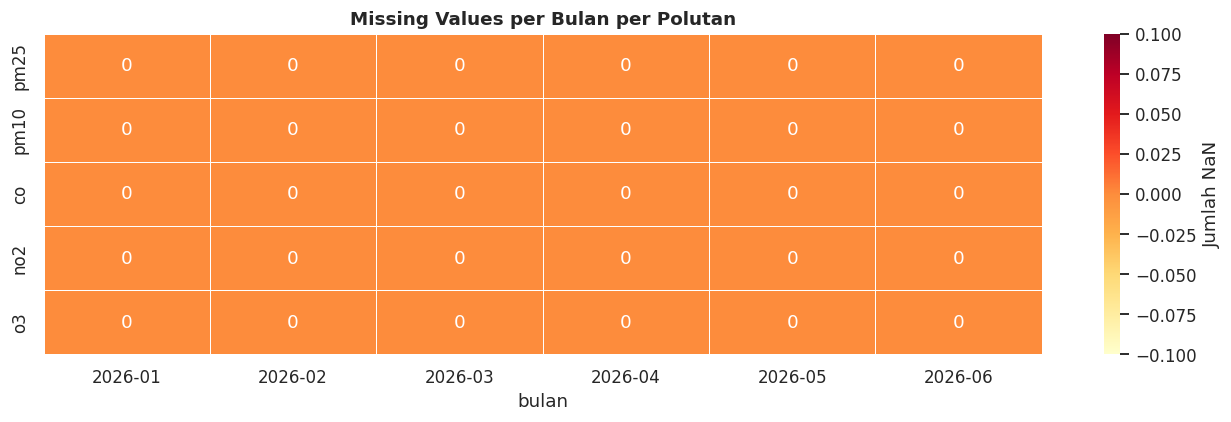

In [6]:
df["bulan"] = df["time"].dt.to_period("M")
mv_monthly = df.groupby("bulan")[POLUTAN].apply(lambda g: g.isnull().sum())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(mv_monthly.T, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Jumlah NaN"})
ax.set_title("Missing Values per Bulan per Polutan", fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_01_missing_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Distribusi Data (Histogram)

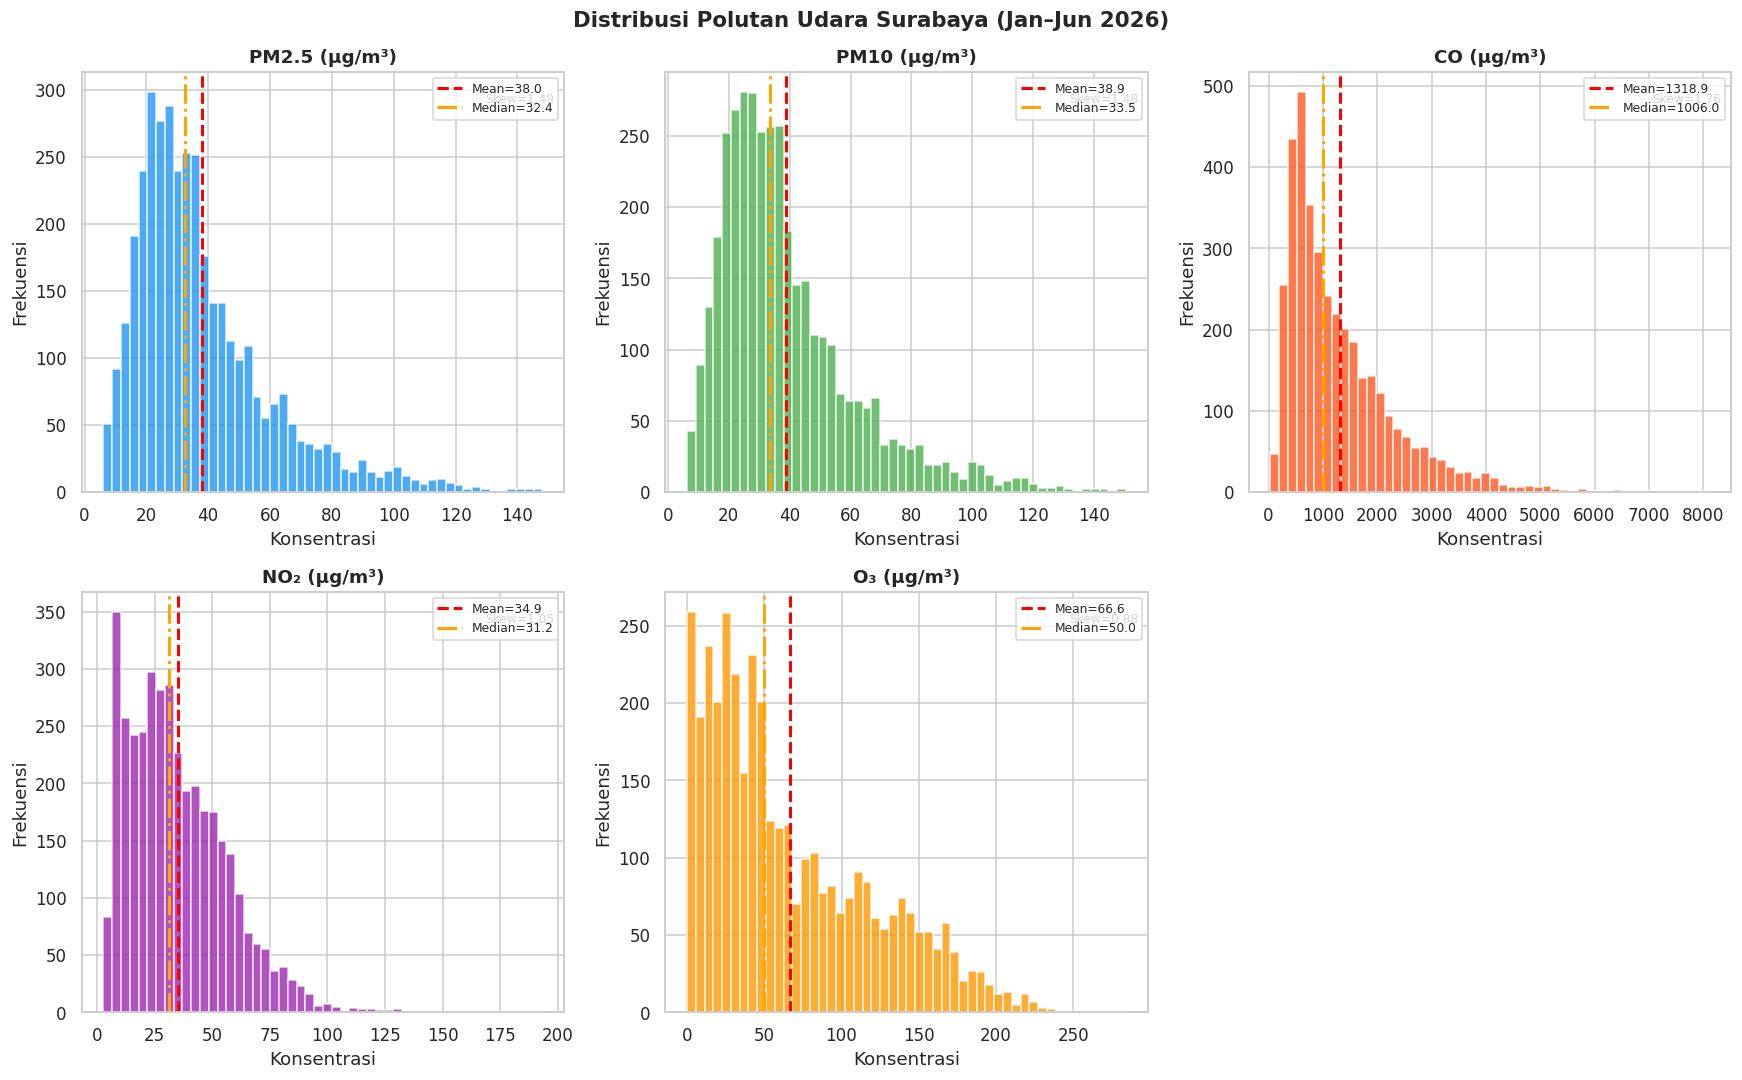

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(POLUTAN, COLORS_POL)):
    data = df[col].dropna()
    ax = axes[i]
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.80)
    ax.axvline(data.mean(), color="red", lw=2, ls="--", label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", lw=2, ls="-.", label=f"Median={data.median():.1f}")
    ax.set_title(LABELS[col], fontweight="bold")
    ax.set_xlabel("Konsentrasi")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)
    ax.text(0.98, 0.95, f"Skew={data.skew():.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

axes[-1].set_visible(False)
plt.suptitle("Distribusi Polutan Udara Surabaya (Jan–Jun 2026)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_02_histogram_polutan.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Outlier Analysis (Boxplot)

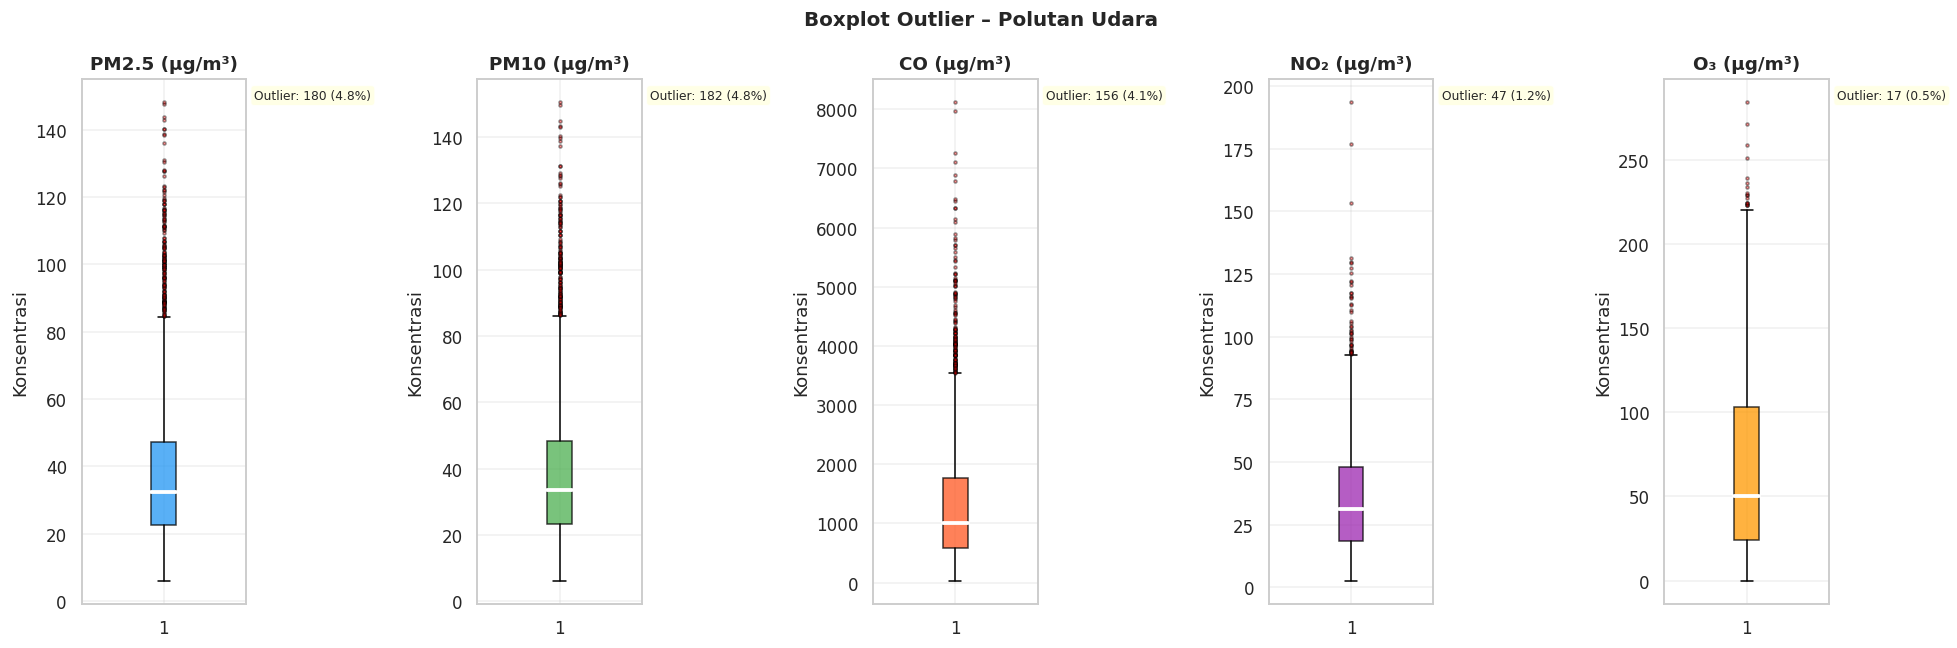

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (col, color) in enumerate(zip(POLUTAN, COLORS_POL)):
    data = df[col].dropna()
    ax = axes[i]
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    medianprops=dict(color="white", linewidth=2.5),
                    flierprops=dict(marker="o", markersize=2, markerfacecolor="red", alpha=0.4))
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.75)

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct_out = n_out / len(data) * 100

    ax.set_title(LABELS[col], fontweight="bold")
    ax.set_ylabel("Konsentrasi")
    ax.text(1.05, 0.98, f"Outlier: {n_out} ({pct_out:.1f}%)",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.suptitle("Boxplot Outlier – Polutan Udara", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_04_boxplot_polutan.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Analisis Temporal

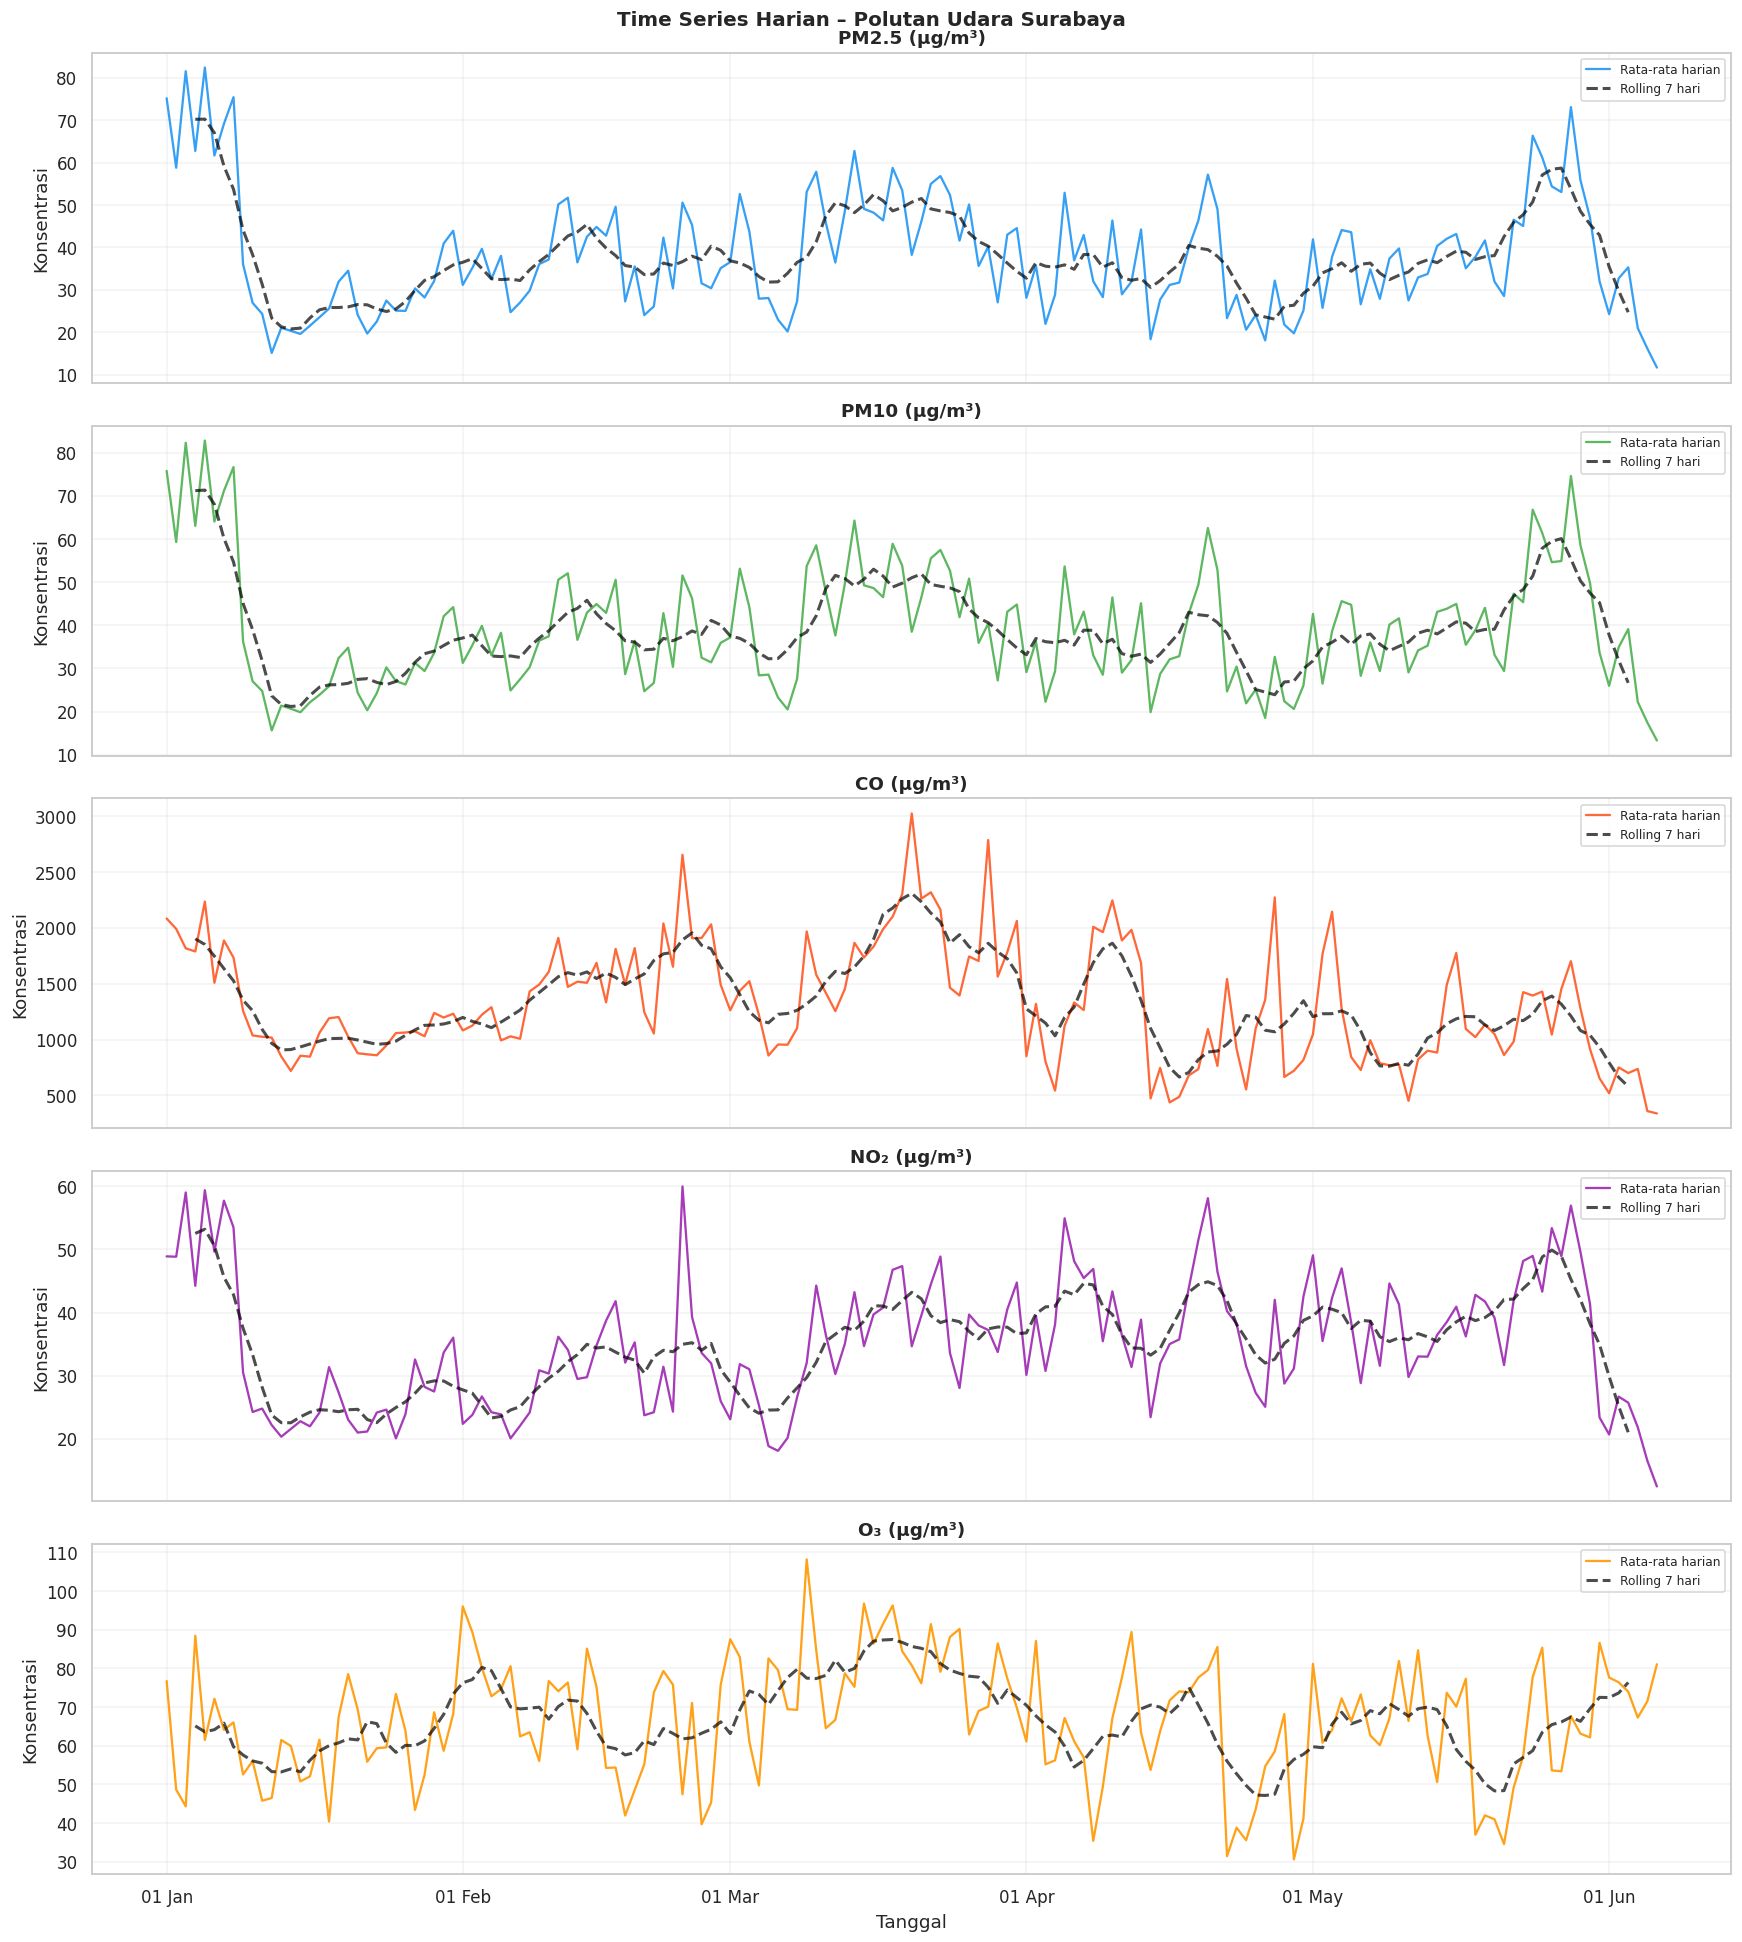

In [9]:
df_daily = df.groupby("date")[POLUTAN].mean().reset_index()
df_daily["date"] = pd.to_datetime(df_daily["date"])

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

for ax, col, color in zip(axes, POLUTAN, COLORS_POL):
    ax.plot(df_daily["date"], df_daily[col], color=color, linewidth=1.5, alpha=0.9, label="Rata-rata harian")
    roll7 = df_daily[col].rolling(7, center=True).mean()
    ax.plot(df_daily["date"], roll7, color="black", linewidth=2, ls="--", alpha=0.7, label="Rolling 7 hari")
    ax.set_title(LABELS[col], fontweight="bold")
    ax.set_ylabel("Konsentrasi")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[-1].set_xlabel("Tanggal")
plt.suptitle("Time Series Harian – Polutan Udara Surabaya", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_05_timeseries_harian.png", dpi=110, bbox_inches="tight")
plt.show()

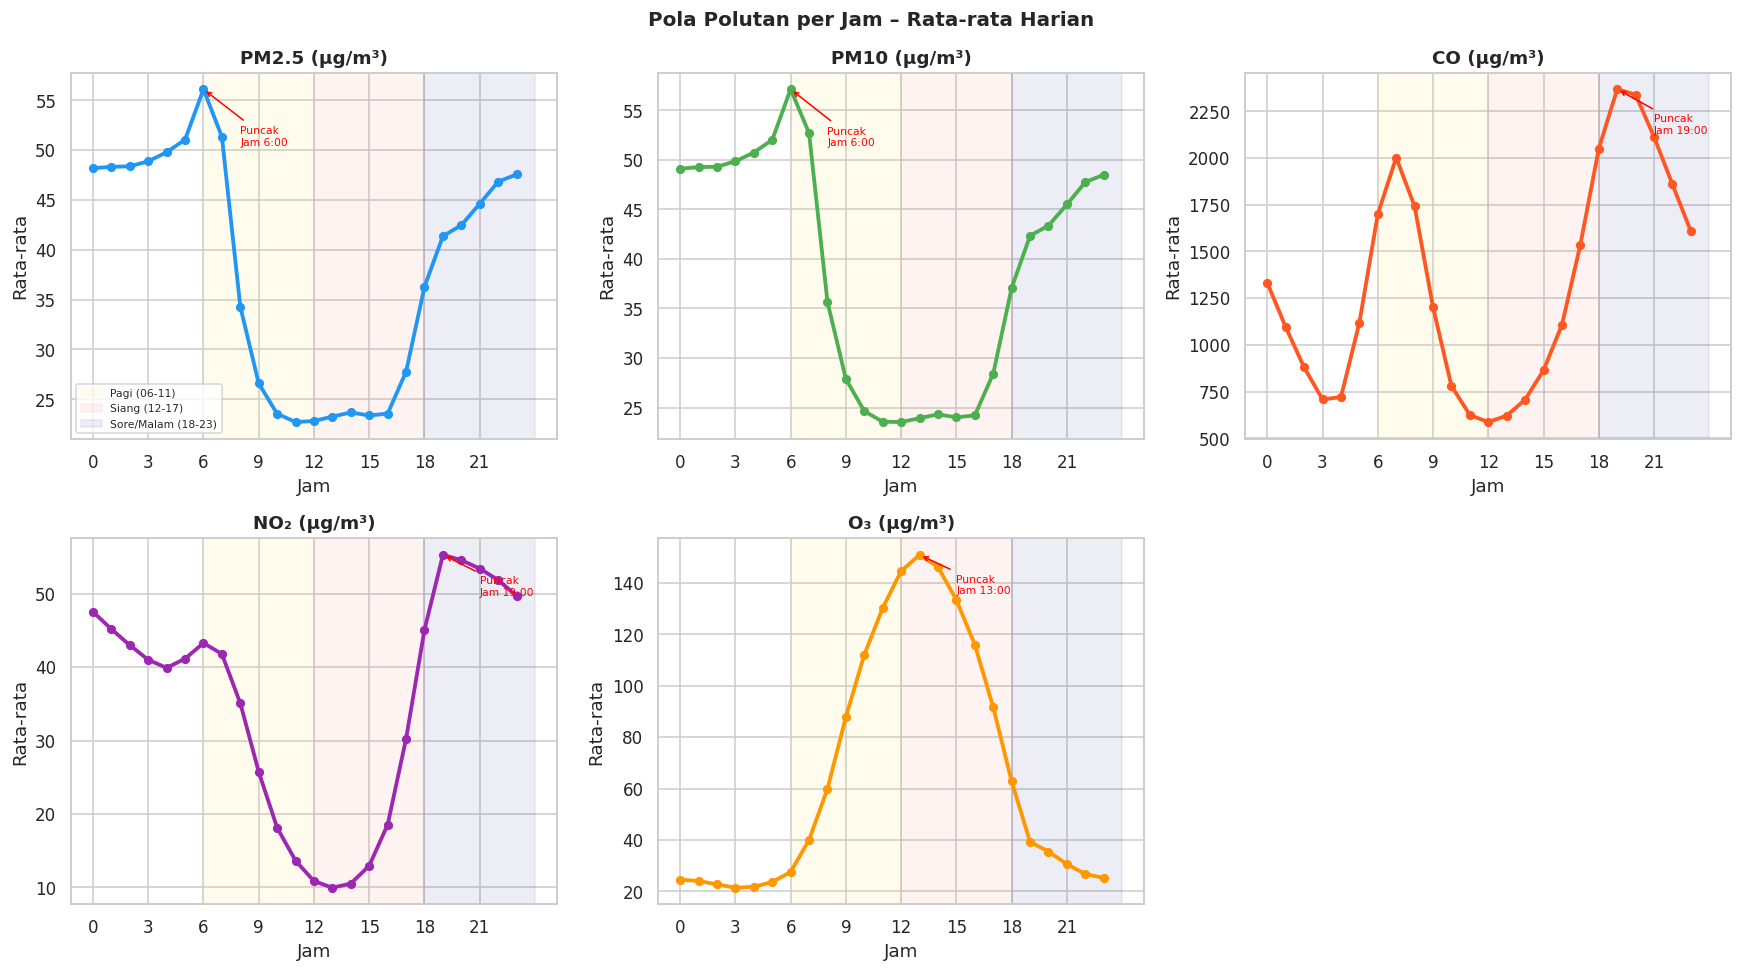

In [10]:
hourly_avg = df.groupby("hour")[POLUTAN].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(POLUTAN, COLORS_POL)):
    ax = axes[i]
    ax.plot(hourly_avg.index, hourly_avg[col], marker="o", color=color, linewidth=2.5, markersize=5)
    ax.axvspan(6, 12, alpha=0.07, color="gold", label="Pagi (06-11)")
    ax.axvspan(12, 18, alpha=0.07, color="tomato", label="Siang (12-17)")
    ax.axvspan(18, 24, alpha=0.07, color="navy", label="Sore/Malam (18-23)")
    peak_hour = hourly_avg[col].idxmax()
    peak_val = hourly_avg[col].max()
    ax.annotate(f"Puncak\nJam {peak_hour}:00", xy=(peak_hour, peak_val),
                xytext=(peak_hour + 2, peak_val * 0.9), arrowprops=dict(arrowstyle="->", color="red"),
                fontsize=7, color="red")
    ax.set_title(LABELS[col], fontweight="bold")
    ax.set_xlabel("Jam")
    ax.set_ylabel("Rata-rata")
    ax.set_xticks(range(0, 24, 3))
    if i == 0:
        ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle("Pola Polutan per Jam – Rata-rata Harian", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_06_pola_per_jam.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Heatmap Korelasi Antar Polutan

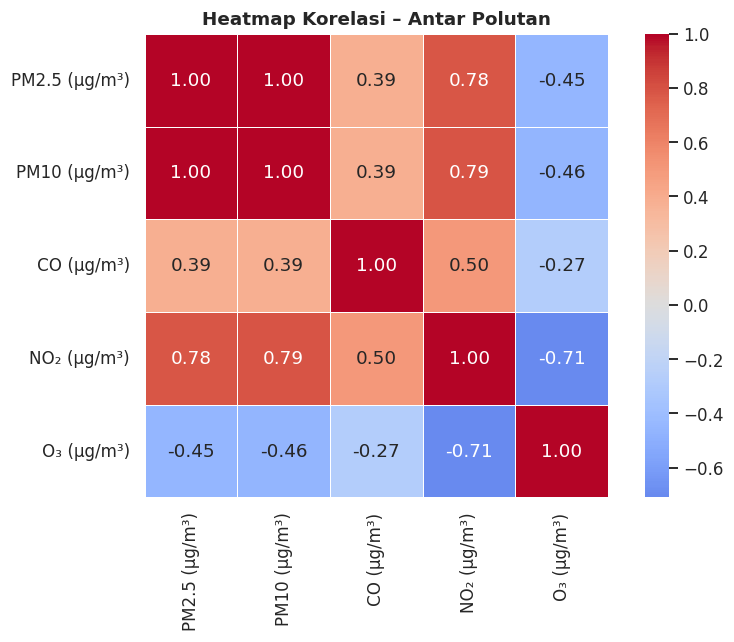

In [11]:
corr_pol = df[POLUTAN].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_pol, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            xticklabels=[LABELS[c] for c in POLUTAN],
            yticklabels=[LABELS[c] for c in POLUTAN])
ax.set_title("Heatmap Korelasi – Antar Polutan", fontweight="bold")
plt.tight_layout()
plt.savefig("reports/eda/eda_09_korelasi_polutan.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Insight Signifikan dari EDA

In [12]:
print("=" * 65)
print("8. INSIGHT SIGNIFIKAN DARI EDA")
print("=" * 65)
print("""
📌 INSIGHT 1 – Distribusi Right-Skewed:
   Semua polutan right-skewed → kebanyakan nilai rendah, sesekali ekstrem tinggi.
   → Implikasi: Class imbalance untuk deteksi anomali.

📌 INSIGHT 2 – Pola Bimodal PM2.5 & CO:
   Puncak jam 07-09 dan 17-19 (rush hour) → sumber utama dari kendaraan.
   → Implikasi: Fitur hour dan time_segment penting.

📌 INSIGHT 3 – Korelasi Kuat PM2.5 & PM10:
   r > 0.8 → sumber emisi sama (kendaraan, debu, industri).
   → Implikasi: Perhatikan multikolinearitas.

📌 INSIGHT 4 – Pola Weekend vs Weekday:
   CO & NO2 lebih rendah di akhir pekan → aktivitas transportasi.
   → Implikasi: Fitur is_weekend relevan.

📌 INSIGHT 5 – Outlier CO & O3:
   Persentase outlier lebih tinggi → potensi event anomali.
   → Implikasi: Outlier jangan dihapus, justru target deteksi anomali.
""")

8. INSIGHT SIGNIFIKAN DARI EDA

📌 INSIGHT 1 – Distribusi Right-Skewed:
   Semua polutan right-skewed → kebanyakan nilai rendah, sesekali ekstrem tinggi.
   → Implikasi: Class imbalance untuk deteksi anomali.

📌 INSIGHT 2 – Pola Bimodal PM2.5 & CO:
   Puncak jam 07-09 dan 17-19 (rush hour) → sumber utama dari kendaraan.
   → Implikasi: Fitur hour dan time_segment penting.

📌 INSIGHT 3 – Korelasi Kuat PM2.5 & PM10:
   r > 0.8 → sumber emisi sama (kendaraan, debu, industri).
   → Implikasi: Perhatikan multikolinearitas.

📌 INSIGHT 4 – Pola Weekend vs Weekday:
   CO & NO2 lebih rendah di akhir pekan → aktivitas transportasi.
   → Implikasi: Fitur is_weekend relevan.

📌 INSIGHT 5 – Outlier CO & O3:
   Persentase outlier lebih tinggi → potensi event anomali.
   → Implikasi: Outlier jangan dihapus, justru target deteksi anomali.



## 9. Ringkasan

In [13]:
print("=" * 65)
print("RINGKASAN EDA – NOTEBOOK 02")
print("=" * 65)
print(f"""
📊 Dataset: {df.shape[0]:,} baris × {df.shape[1]} kolom
   Rentang: {df['time'].min().date()} → {df['time'].max().date()}

✅ Visualisasi tersimpan di reports/eda/:
   - eda_01_missing_heatmap.png
   - eda_02_histogram_polutan.png
   - eda_04_boxplot_polutan.png
   - eda_05_timeseries_harian.png
   - eda_06_pola_per_jam.png
   - eda_09_korelasi_polutan.png

✅ Insight: 5 insight signifikan

📌 Next → Notebook 03: Preprocessing & Feature Engineering
""")

RINGKASAN EDA – NOTEBOOK 02

📊 Dataset: 3,768 baris × 13 kolom
   Rentang: 2026-01-01 → 2026-06-06

✅ Visualisasi tersimpan di reports/eda/:
   - eda_01_missing_heatmap.png
   - eda_02_histogram_polutan.png
   - eda_04_boxplot_polutan.png
   - eda_05_timeseries_harian.png
   - eda_06_pola_per_jam.png
   - eda_09_korelasi_polutan.png

✅ Insight: 5 insight signifikan

📌 Next → Notebook 03: Preprocessing & Feature Engineering

